In [1]:
from py_madaclim.info import MadaclimLayers

In [2]:
# Instantiate the MadaclimLayers without the rasters
mada_info = MadaclimLayers()

print(mada_info)

MadaclimLayers(
	all_layers = DataFrame(79 rows x 6 columns)
	categorical_layers = DataFrame(Layers 75, 76, 77, 78 with a total of 79 categories
	public methods -> download_data, fetch_specific_layers, get_categorical_combinations
			 get_layers_labels, select_geoclim_type_layers
)


Option for a more detailed label format

In [3]:
# Get a single layer with a more descriptive label
mada_info.get_layers_labels(69, as_descriptive_labels=True)

['clim_69_cwd_Annual climatic water deficit (mm)']

Extract a subset of layers based on layer number and taking advantage of the descriptive naming structure of the `as_descriptive_out` output:

 \<geoclim_type>\_\<dasd>\_\<unique_layername>\_\<details>

In [10]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)  # Disable line-wrapping
pd.set_option('display.max_rows', None)

### Raster files specific methods

In [4]:
from pathlib import Path
cwd = Path.cwd()

raster_files = ["madaclim_current.tif", "madaclim_enviro.tif"]
if not all([(cwd / raster_file).exists() for raster_file in raster_files]):
    mada_info.download_data(save_dir=cwd)


####   Trying get request to Madaclim website...   ####
madaclim_current.tif is 21.8 MB
Server response OK from madaclim.cirad.fr, starting to download madaclim_current.tif
Progress for madaclim_current.tif : 100.00 % completed of 21.8 MB downloaded [ average speed of  3.6 MB/s ]
Done downloading madaclim_current.tif in 6.07 seconds !

####   Trying get request to Madaclim website...   ####
madaclim_enviro.tif is 5.5 MB
Server response OK from madaclim.cirad.fr, starting to download madaclim_enviro.tif
Progress for madaclim_enviro.tif : 100.00 % completed of 5.5 MB downloaded [ average speed of  3.0 MB/s ]
Done downloading madaclim_enviro.tif in 1.84 seconds !


In [5]:
print([file.name for file in cwd.iterdir() if file.suffix == ".tif"])

['madaclim_current.tif', 'madaclim_enviro.tif']


Setting the raster-related attributes of the `mada_info` instance

In [6]:
mada_info.clim_raster = "./madaclim_current.tif"
mada_info.env_raster = "./madaclim_enviro.tif"
print(mada_info)    # Now the 'get_bandnums_from_layers' is visible

MadaclimLayers(
	all_layers = DataFrame(79 rows x 6 columns)
	categorical_layers = DataFrame(Layers 75, 76, 77, 78 with a total of 79 categories
	clim_raster = madaclim_current.tif
	clim_crs = EPSG:32738
	env_raster = madaclim_enviro.tif
	env_crs = EPSG:32738
	public methods -> download_data, fetch_specific_layers, get_bandnums_from_layers
			 get_categorical_combinations, get_layers_labels, select_geoclim_type_layers
)


In [7]:
MadaclimLayers(clim_raster="madaclim_current.tif", env_raster="madaclim_enviro.tif")

MadaclimLayers(
	all_layers = DataFrame(79 rows x 6 columns)
	categorical_layers = DataFrame(Layers 75, 76, 77, 78 with a total of 79 categories
	clim_raster = madaclim_current.tif
	clim_crs = EPSG:32738
	env_raster = madaclim_enviro.tif
	env_crs = EPSG:32738
	public methods -> download_data, fetch_specific_layers, get_bandnums_from_layers
			 get_categorical_combinations, get_layers_labels, select_geoclim_type_layers
)

### Using layers label to visualize the raster maps

Instantiate a `MadaclimRasters` object

In [8]:
from py_madaclim.raster_manipulation import MadaclimRasters

mada_rasters = MadaclimRasters(clim_raster=cwd / "madaclim_current.tif", env_raster=cwd / "madaclim_enviro.tif")
print(mada_rasters)

MadaclimRasters(
	clim_raster = madaclim_current.tif,
	clim_crs = EPSG:32738,
	clim_nodata_val = -32768.0
	env_raster = madaclim_enviro.tif,
	env_crs = EPSG:32738,
	env_nodata_val = -32768.0
)


**Continuous layers visualization**

Using the `plot_layer` method, we can look at a single layer for the whole map of madagascar

c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


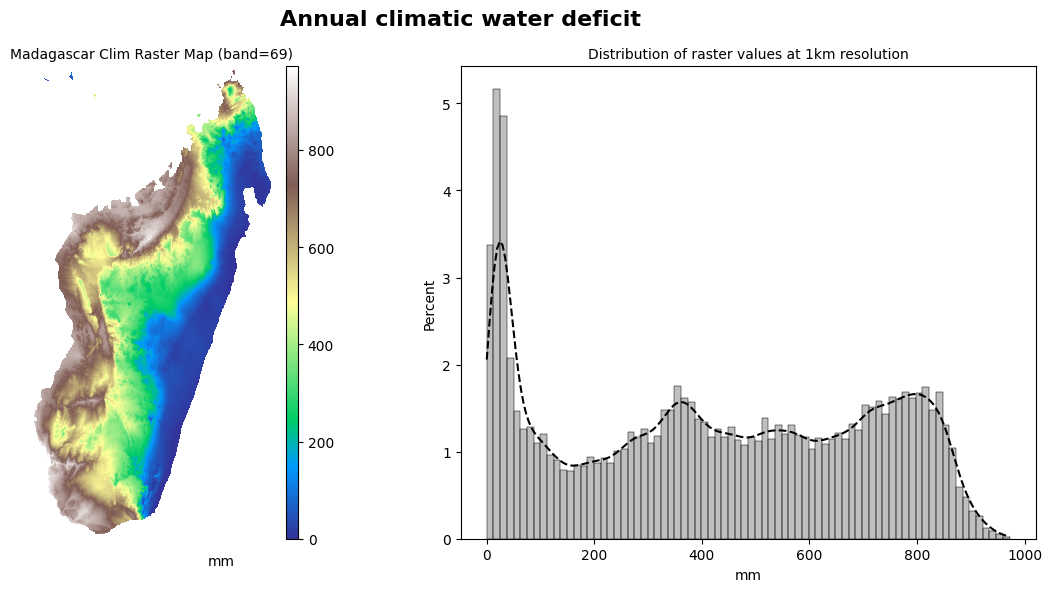

In [9]:
# Default visualization
mada_rasters.plot_layer(69, imshow_cmap="terrain");    # Also accepts layer="layer_71"

Excellent visual, Caro — this is clear, well-structured, and already very informative. It maps the *Coffea* growth cycle across a year-by-year timeline, differentiating rainy and dry seasons and overlaying key developmental stages. You're off to a strong start!

---

## ✅ Polished Caption (LaTeX or manuscript use):

> **Figure\~X.** Annual growth cycle of *Coffea* species in highly seasonal environments with extended dry periods. This schematic represents the phenological timeline typical of habitat types characterized by more than six months of dry season. The cycle spans four years post-germination, illustrating key stages including seedling emergence, vegetative growth, flowering, and fruit development. The rainy season (November–March) aligns with early growth and resource allocation, while the dry season (April–October) overlaps with flowering and fruit maturation. The striped symbols indicate periods critical for secondary metabolite accumulation, notably caffeine. This timeline provides a conceptual baseline for habitat-specific comparisons across botanical series.

---

## 🔧 Improvement Recommendations

### 1. **Indicate habitat explicitly in figure title or legend**

Since this represents **Habitat 3**, make that visually explicit:

* Update the title in the figure to:

  ```
  Coffea Growth Cycle – Extended Dry Season (Habitat 3)
  ```

### 2. **Color or label rainy vs dry season in the upper band**

Currently there’s a blue/yellow hint — but labeling could be bolder:

* Add text above:
  **"Rainy Season"** and **"Dry Season"** directly above the month bars.
* Use transparent shaded bands under months to emphasize seasonality.

### 3. **Add a subtle legend (if not in the caption)**

To clarify meaning of:

* Red striped circles → secondary metabolite window
* Green/yellow/orange stages → flowering/fruiting periods (or whatever is intended)

---

## 🌱 Integrating Botanical Series (if needed)

If species in different botanical series exhibit distinct growth rhythms (e.g. **flower earlier or fruit over different months**), here are options:

### Option 1 – Textual Description Only (minimal)

In the discussion:

> While the general structure of the growth cycle remains consistent, the timing and duration of flowering and fruit development vary among botanical series. For instance, species within the *Millotii complex* tend to initiate flowering earlier than those in the *Multiflorae* series under the same habitat conditions.

### Option 2 – Color-Coded Tracks in Diagram (advanced)

If feasible, add **multiple tracks per year row**, each for a botanical series (e.g., *Millotii*, *Garcinioides*, *Multiflorae*) with:

* Slight vertical separation
* Label at left
* Shared month axis

This works best for a **summary timeline** in a figure like “Habitat 3 — Botanical Series Comparison”.

### Option 3 – Summary Table as Supplement

A table listing:

| Botanical Series | Flowering Period | Fruiting Period | Notable Differences     |
| ---------------- | ---------------- | --------------- | ----------------------- |
| Millotii complex | April–June       | July–Sept       | Shorter fruiting window |
| Multiflorae      | May–July         | Aug–Oct         | Later flowering         |

---

Would you like help generating diagrams for Habitats 1 and 2 with similar formatting? I can also help design a compact figure legend or color key if needed.


Pass in any number of kwargs to the imshow or cax (raster + colorbarax) or histplot or subplots for customization

In [49]:
env_labels = mada_info.get_layers_labels(
    layers_subset="env", 
    as_descriptive_labels=True
)
env_labels

['env_71_alt_Altitude (meters)',
 'env_72_slo_Slope (degrees)',
 'env_73_asp_Aspect; clockwise from North (degrees)',
 'env_74_solrad_Solar radiation; computed from altitude, slope and aspect (Wh.m-2.day-1)',
 'env_75_geo_Rock types (categ_vals: 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13)',
 'env_76_soi_Soil types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23)',
 'env_77_veg_Vegetation types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 22, 23, 25)',
 'env_78_wat_Watersheds (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25)',
 'env_79_forcov_Percentage of forest cover in 1 km by 1 km grid cells (%)']

c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


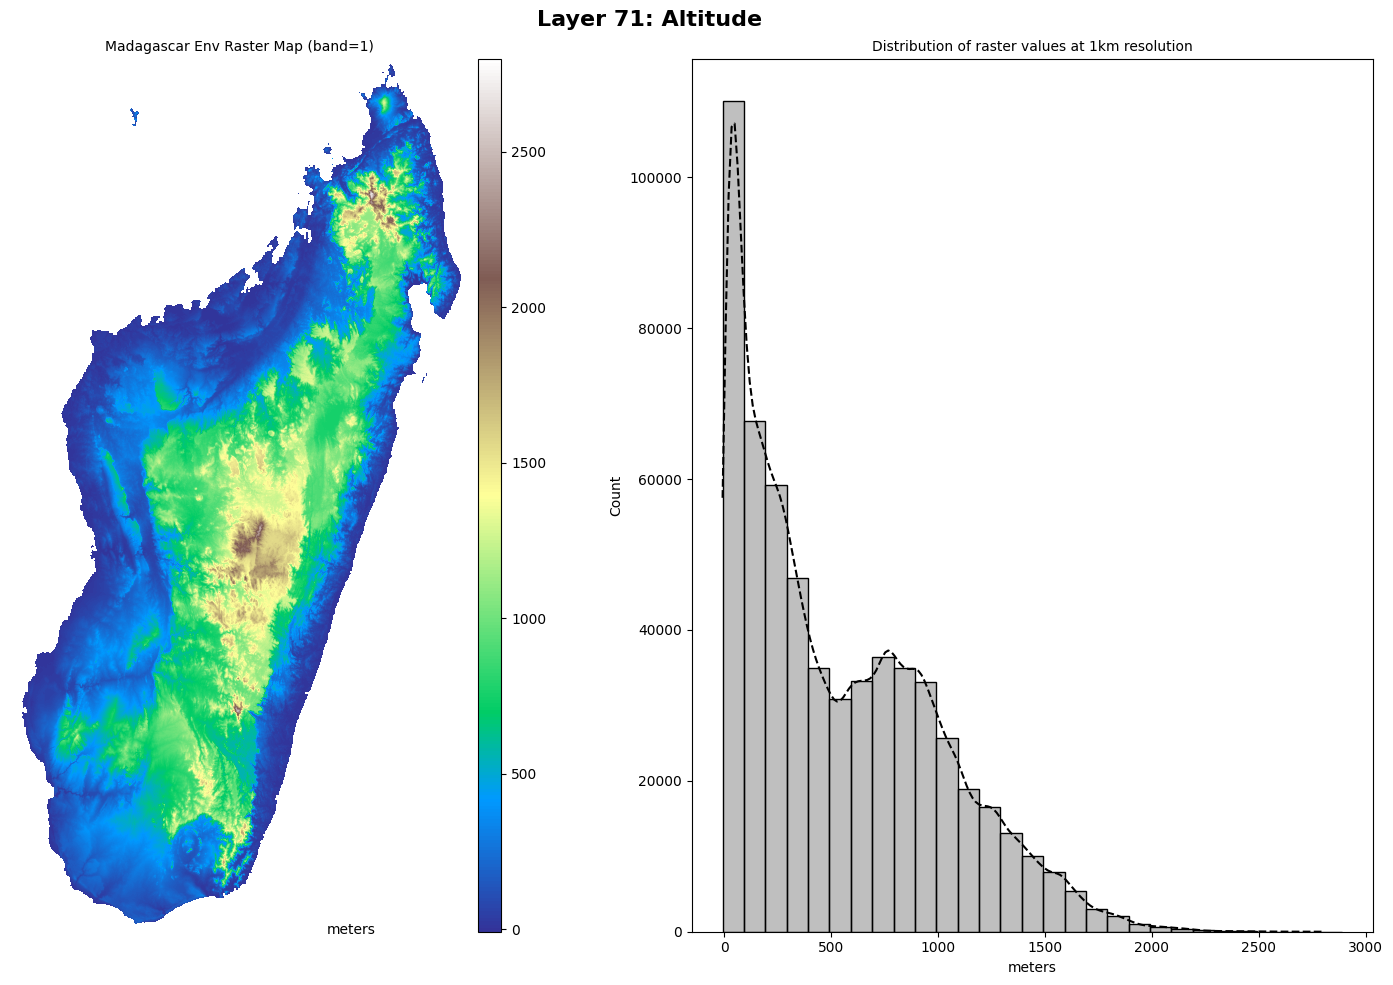

In [50]:
mada_rasters.plot_layer(
    layer=env_labels[0], 
    imshow_cmap="terrain", 
    histplot_binwidth=100, histplot_stat="count", 
    subplots_figsize=(15, 10)
);

For numerical features with highly skewed distribution, specify vmin or vmax for the raster map to at least have a better colorbar scaling

c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


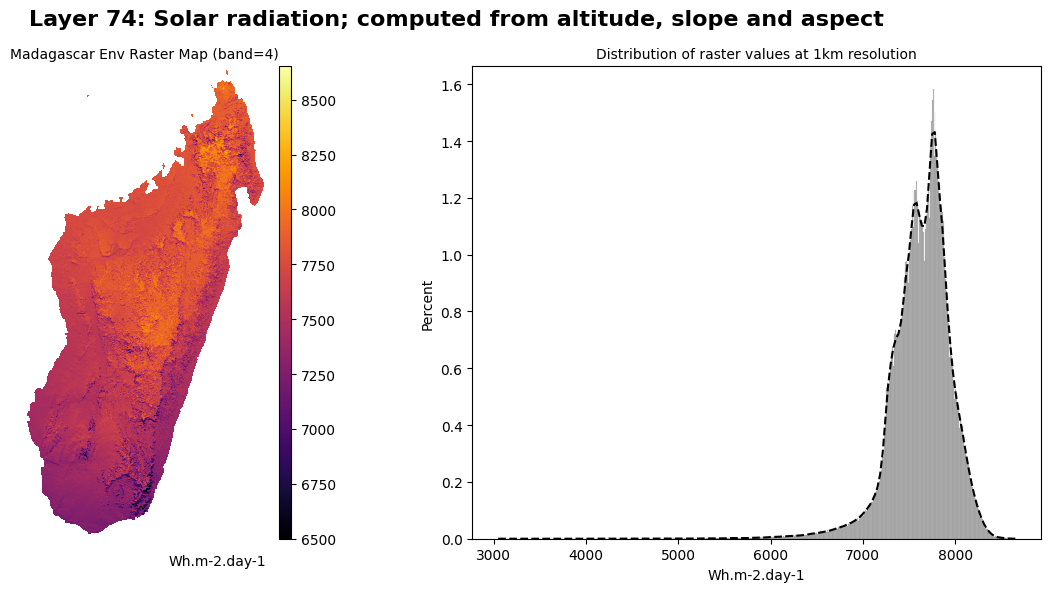

In [133]:
# For numerical features with highly skewed distribution, specify vmin or vmax for the raster map
mada_rasters.plot_layer(layer=env_labels[3], imshow_vmin=6500);

**Categorical layers visualization**

In [134]:
categ_layers = mada_info.get_categorical_combinations(as_descriptive_keys=True)
print(f"There are {len(categ_layers)} categorical layers in the Madaclim db:\n")
for layer in categ_layers:
    print(layer)

There are 4 categorical layers in the Madaclim db:

env_75_geo_Rock types (categ_vals: 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13)
env_76_soi_Soil types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23)
env_77_veg_Vegetation types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 22, 23, 25)
env_78_wat_Watersheds (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25)


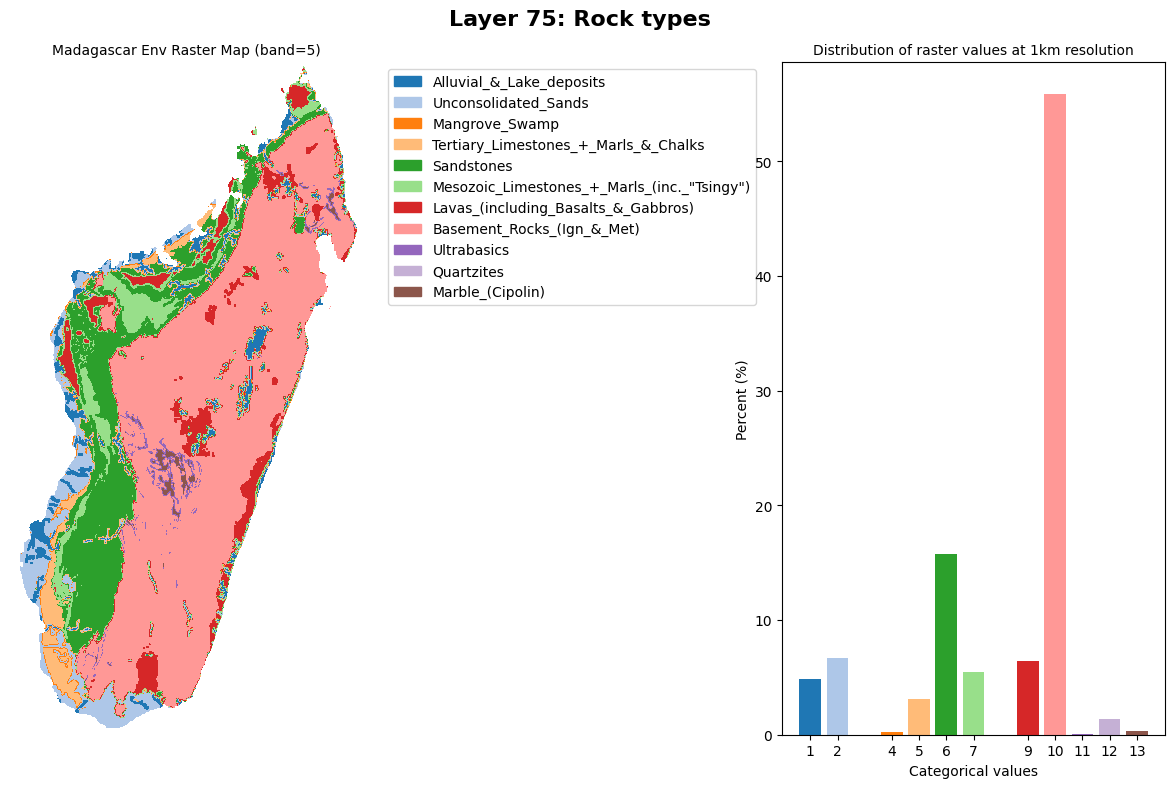

In [135]:
mada_rasters.plot_layer(list(categ_layers.keys())[0], subplots_figsize=(12, 8));

## Create a sample point and extract/visualize data from the rasters using `MadaclimPoint`

### Geographic location and CRS validation of the sample

Create a MadaclimPoint instance with required parameters `specimen_id`, `longitude`, `latitude`

In [136]:
from py_madaclim.raster_manipulation import MadaclimPoint

specimen_1 = MadaclimPoint(
    specimen_id="abbayesii", 
    longitude=46.8624,    # Default CRS of EPSG:4326
    latitude=-24.7541
    )
print(specimen_1)

MadaclimPoint(
	specimen_id = abbayesii,
	source_crs = 4326,
	longitude = 46.8624,
	latitude = -24.7541,
	mada_geom_point = POINT (688328.2403248843 7260998.022932809),
	sampled_layers = None (Not sampled yet),
	nodata_layers = None (Not sampled yet),
	is_categorical_encoded = False,
	gdf.shape = (1, 8)
)


Creates a shapely point object according to the Madaclim CRS' projection when instantiating a new instance

In [137]:
print(f"Shapely point geometry for {specimen_1.specimen_id}: {specimen_1.mada_geom_point}")
print(f"The projection of the Madaclim rasters': {mada_rasters.clim_crs}")

Shapely point geometry for abbayesii: POINT (688328.2403248843 7260998.022932809)
The projection of the Madaclim rasters': EPSG:32738


Uses default EPSG:4326 CRS for both lat/lon when not specified. 

The constructor assumes that lat/lon are in the 4326 (GPS) projection. If a source_crs is given, it will validate the lat/lon if it is within possible bounds

In [138]:
specimen_1.source_crs    

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Regardless of the `source_crs` argument passed, the constructor will validate if the point can be reprojected to EPSG:32738. Thus samples must be located on Madagascar only

In [139]:
try:
    error_test = MadaclimPoint(specimen_id="error_test", latitude=55123, longitude=-123123, source_crs=3333)
except ValueError as e:
    print(e)

longitude=-123123.0 is out of bounds of the Madaclim rasters' for error_test.
Longitude must fall between 6379618.136561 and 7617913.891767 (according to `source_crs`).


The `MadaclimPoint` constructor also accepts any other `kwargs` and saves them as attributes with the relevant type

In [140]:
spe1_info = {
    "genus": "Coffea",
    'species': 'abbayesii',
    'specimen_id': 'ABA',
    'has_sequencing': True,
    'botanical_series': 'Millotii',
    'genome_size (2C. pg)': 1.25,
    'latitude': -24.7541,
    'longitude': 46.8624
}

spe1 = MadaclimPoint(**spe1_info)
print(spe1)

MadaclimPoint(
	specimen_id = ABA,
	source_crs = 4326,
	longitude = 46.8624,
	latitude = -24.7541,
	mada_geom_point = POINT (688328.2403248843 7260998.022932809),
	sampled_layers = None (Not sampled yet),
	nodata_layers = None (Not sampled yet),
	is_categorical_encoded = False,
	genus = Coffea,
	species = abbayesii,
	has_sequencing = 1.0,
	botanical_series = Millotii,
	genome_size (2C. pg) = 1.25,
	gdf.shape = (1, 13)
)


Access the Geodataframe attribute with updated attributes

In [141]:
spe1.gdf

,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded,genus,species,has_sequencing,botanical_series,genome_size (2C. pg)
0,ABA,4326,46.8624,-24.7541,POINT (688328.240 7260998.023),None,None,False,Coffea,abbayesii,1.0,Millotii,1.25


Access all categories pooled together in a single list

In [142]:
#* CHECK
spe1.encoded_categ_labels

### Sample the rasters for a MadaclimPoint and change its state

We will sample the rasters based on the MadaclimPoint's location (`mada_geom_point` `Point` geometry) using the `sample_from_rasters` method.

In [143]:
print(spe1.sampled_layers)

None


In [144]:
print(f"Layers sampled for {spe1.specimen_id}: {spe1.sampled_layers}")

spe1.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster, 
    env_raster=mada_rasters.env_raster, 
    layers_to_sample=[37, 55, 75],    # from a list of number layers
)

print(f"Layers sampled for {spe1.specimen_id}: {spe1.sampled_layers}")    # Updated `sampled_layers` dict

Layers sampled for ABA: None

######################################## Extracting data for: ABA ########################################

Sampling 2 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 55: Precipitation of coldest quarter:  100%|██████████| layer 2/2 [Time remaining: 00:00]



Sampling 1 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 75: Rock types:  100%|██████████| layer 1/1 [Time remaining: 00:00]


Finished raster sampling operation in 0.04 seconds.

Layers sampled for ABA: {'layer_37': np.int16(215), 'layer_55': np.int16(188), 'layer_75': np.int16(10)}


We can customize the sampling procedure with the `layers_to_sample` and `layer_info` parameters.

In [145]:
# Extract and sample bioclim layers for spe1
bioclim_labels = [label for label in mada_info.get_layers_labels(as_descriptive_labels=True) if "bio" in label]
print(f"Sampling layers: {', '.join([label.split('_', 3)[-1] for label in bioclim_labels])}")

spe1.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster, 
    env_raster=mada_rasters.env_raster, 
    layers_to_sample=bioclim_labels,
    layer_info=True
)
print()
print(f"There are {len(spe1.nodata_layers) if spe1.nodata_layers else 0} sampled layers with missing values")


Sampling layers: Annual mean temperature (degrees), Mean diurnal range (mean of monthly max temp - monthy min temp), Isothermality = BIO2/BIO7 x 100 (No units), Temperature seasonality (standard deviation x 100), Max temperature of warmest month (degrees), Min temperature of coldest month (degrees), Temperature annual range  = BIO5-BIO6 (degrees), Mean temperature of wettest quarter (degrees), Mean temperature of driest quarter (degrees), Mean temperature of warmest quarter (degrees), Mean temperature of coldest quarter (degrees), Annual precipitation (mm.year-1), Precipitation of wettest month (mm), Precipitation of driest month (mm), Precipitation seasonality (coefficient of variation), Precipitation of wettest quarter (mm.3months-1), Precipitation of driest quarter (mm.3months-1), Precipitation of warmest quarter (mm.3months-1), Precipitation of coldest quarter (mm.3months-1)

######################################## Extracting data for: ABA ########################################


Extracting layer 55: Precipitation of coldest quarter:  100%|██████████| layer 19/19 [Time remaining: 00:00]   


Finished raster sampling operation in 0.10 seconds.


There are 0 sampled layers with missing values


We can access the values and updated attributes to visualize the changes to the instance.

In [146]:
print(spe1)    # Updated attributes and Geodataframe

MadaclimPoint(
	specimen_id = ABA,
	source_crs = 4326,
	longitude = 46.8624,
	latitude = -24.7541,
	mada_geom_point = POINT (688328.2403248843 7260998.022932809),
	len(sampled_layers) = 19 layer(s),
	len(nodata_layers) = None (0 layers),
	is_categorical_encoded = False,
	genus = Coffea,
	species = abbayesii,
	has_sequencing = 1.0,
	botanical_series = Millotii,
	genome_size (2C. pg) = 1.25,
	gdf.shape = (1, 32)
)


In [147]:
spe1.sampled_layers    # Dynamically updated attributes

{'clim_37_bio1_Annual mean temperature (degrees)': np.int16(215),
 'clim_38_bio2_Mean diurnal range (mean of monthly max temp - monthy min temp)': np.int16(112),
 'clim_39_bio3_Isothermality = BIO2/BIO7 x 100 (No units)': np.int16(63),
 'clim_40_bio4_Temperature seasonality (standard deviation x 100)': np.int16(2597),
 'clim_41_bio5_Max temperature of warmest month (degrees)': np.int16(297),
 'clim_42_bio6_Min temperature of coldest month (degrees)': np.int16(120),
 'clim_43_bio7_Temperature annual range  = BIO5-BIO6 (degrees)': np.int16(177),
 'clim_44_bio8_Mean temperature of wettest quarter (degrees)': np.int16(238),
 'clim_45_bio9_Mean temperature of driest quarter (degrees)': np.int16(186),
 'clim_46_bio10_Mean temperature of warmest quarter (degrees)': np.int16(238),
 'clim_47_bio11_Mean temperature of coldest quarter (degrees)': np.int16(180),
 'clim_48_bio12_Annual precipitation (mm.year-1)': np.int16(1260),
 'clim_49_bio13_Precipitation of wettest month (mm)': np.int16(204),
 

We can use the `MadaclimLayers` labels to access specific columns of the updated Geodataframe

In [148]:
spe1.gdf[bioclim_labels]

,clim_37_bio1_Annual mean temperature (degrees),clim_38_bio2_Mean diurnal range (mean of monthly max temp - monthy min temp),clim_39_bio3_Isothermality = BIO2/BIO7 x 100 (No units),clim_40_bio4_Temperature seasonality (standard deviation x 100),clim_41_bio5_Max temperature of warmest month (degrees),clim_42_bio6_Min temperature of coldest month (degrees),clim_43_bio7_Temperature annual range = BIO5-BIO6 (degrees),clim_44_bio8_Mean temperature of wettest quarter (degrees),clim_45_bio9_Mean temperature of driest quarter (degrees),clim_46_bio10_Mean temperature of warmest quarter (degrees),clim_47_bio11_Mean temperature of coldest quarter (degrees),clim_48_bio12_Annual precipitation (mm.year-1),clim_49_bio13_Precipitation of wettest month (mm),clim_50_bio14_Precipitation of driest month (mm),clim_51_bio15_Precipitation seasonality (coefficient of variation),clim_52_bio16_Precipitation of wettest quarter (mm.3months-1),clim_53_bio17_Precipitation of driest quarter (mm.3months-1),clim_54_bio18_Precipitation of warmest quarter (mm.3months-1),clim_55_bio19_Precipitation of coldest quarter (mm.3months-1)
0,215,112,63,2597,297,120,177,238,186,238,180,1260,204,44,56,484,159,484,188


**Sampling categorical data**

The categorical layers can be accessed with the `get_categorical_combinations` from a `MadaclimLayers` instance

In [149]:
categ_layers = mada_info.get_categorical_combinations()
categ_layers["layer_75"]

{1: 'Alluvial_&_Lake_deposits',
 2: 'Unconsolidated_Sands',
 4: 'Mangrove_Swamp',
 5: 'Tertiary_Limestones_+_Marls_&_Chalks',
 6: 'Sandstones',
 7: 'Mesozoic_Limestones_+_Marls_(inc._"Tsingy")',
 9: 'Lavas_(including_Basalts_&_Gabbros)',
 10: 'Basement_Rocks_(Ign_&_Met)',
 11: 'Ultrabasics',
 12: 'Quartzites',
 13: 'Marble_(Cipolin)'}

In [150]:
# Sampling all possible data will contain the 4 categorical layers
spe1.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster, 
    env_raster=mada_rasters.env_raster,
)


######################################## Extracting data for: ABA ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.38 seconds.



Since we extracted all the layers possible in the example, some categorical data has been sampled.

In [151]:
print(spe1.is_categorical_encoded)

False


In [152]:
sampled_categ_layers = {layer: val for layer, val in spe1.sampled_layers.items() if layer in categ_layers}
for layer, raster_value in sampled_categ_layers.items():
    print(
        f"Categorical {layer} has a {raster_value=} for {spe1._specimen_id} "
        f"at position lon/lat=({spe1.longitude}, {spe1.latitude})"
    )

Categorical layer_75 has a raster_value=np.int16(10) for ABA at position lon/lat=(46.8624, -24.7541)
Categorical layer_76 has a raster_value=np.int16(9) for ABA at position lon/lat=(46.8624, -24.7541)
Categorical layer_77 has a raster_value=np.int16(14) for ABA at position lon/lat=(46.8624, -24.7541)
Categorical layer_78 has a raster_value=np.int16(5) for ABA at position lon/lat=(46.8624, -24.7541)


In [153]:
spe1.gdf[sampled_categ_layers.keys()]

,layer_75,layer_76,layer_77,layer_78
0,10,9,14,5


Encode the categorical layers using `binary_encode_categorical`

In [154]:
spe1.binary_encode_categorical()
print(spe1.is_categorical_encoded)
print(f"Shape of geodataframe post one-hot-encoding: {spe1.gdf.shape}")

True
Shape of geodataframe post one-hot-encoding: (1, 171)


The changes are reflected in the `encoded_categ_layers` attribute

In [155]:
# print(spe1.encoded_categ_layers)
spe1.encoded_categ_layers

{'layer_75_Alluvial_&_Lake_deposits': 0,
 'layer_75_Basement_Rocks_(Ign_&_Met)': 1,
 'layer_75_Lavas_(including_Basalts_&_Gabbros)': 0,
 'layer_75_Mangrove_Swamp': 0,
 'layer_75_Marble_(Cipolin)': 0,
 'layer_75_Mesozoic_Limestones_+_Marls_(inc._"Tsingy")': 0,
 'layer_75_Quartzites': 0,
 'layer_75_Sandstones': 0,
 'layer_75_Tertiary_Limestones_+_Marls_&_Chalks': 0,
 'layer_75_Ultrabasics': 0,
 'layer_75_Unconsolidated_Sands': 0,
 'layer_75__nodata': 0,
 'layer_76_Alluvio-colluvial_Deposited_Soils': 0,
 'layer_76_Andosols': 1,
 'layer_76_Bare_Rocks': 0,
 'layer_76_Fluvio-marine_Deposited_Soils_-_Mangroves': 0,
 'layer_76_Highly_Rejuvenated,_Penevoluted_Ferralitic_Soils': 0,
 'layer_76_Humic_Ferralitic_Soils': 0,
 'layer_76_Humic_Rejuvenated_Ferralitic_Soils': 0,
 'layer_76_Hydromorphic_Soils': 0,
 'layer_76_Indurated-Concretion_Ferralitic_Soils': 0,
 'layer_76_Podzolic_Soils_and_Podzols': 0,
 'layer_76_Poorly_Evolved_Erosion_Soils,_Lithosols': 0,
 'layer_76_Raw_Lithic_Mineral_Soils': 0,


### Visualize a specimen's sampled value on the raster's map and distribution

Default visualizations of a MadaclimPoint on the raster map and raster distribution plot. Note that the vline is drawn were the value for the sampled_layer of the given specimen_id is.

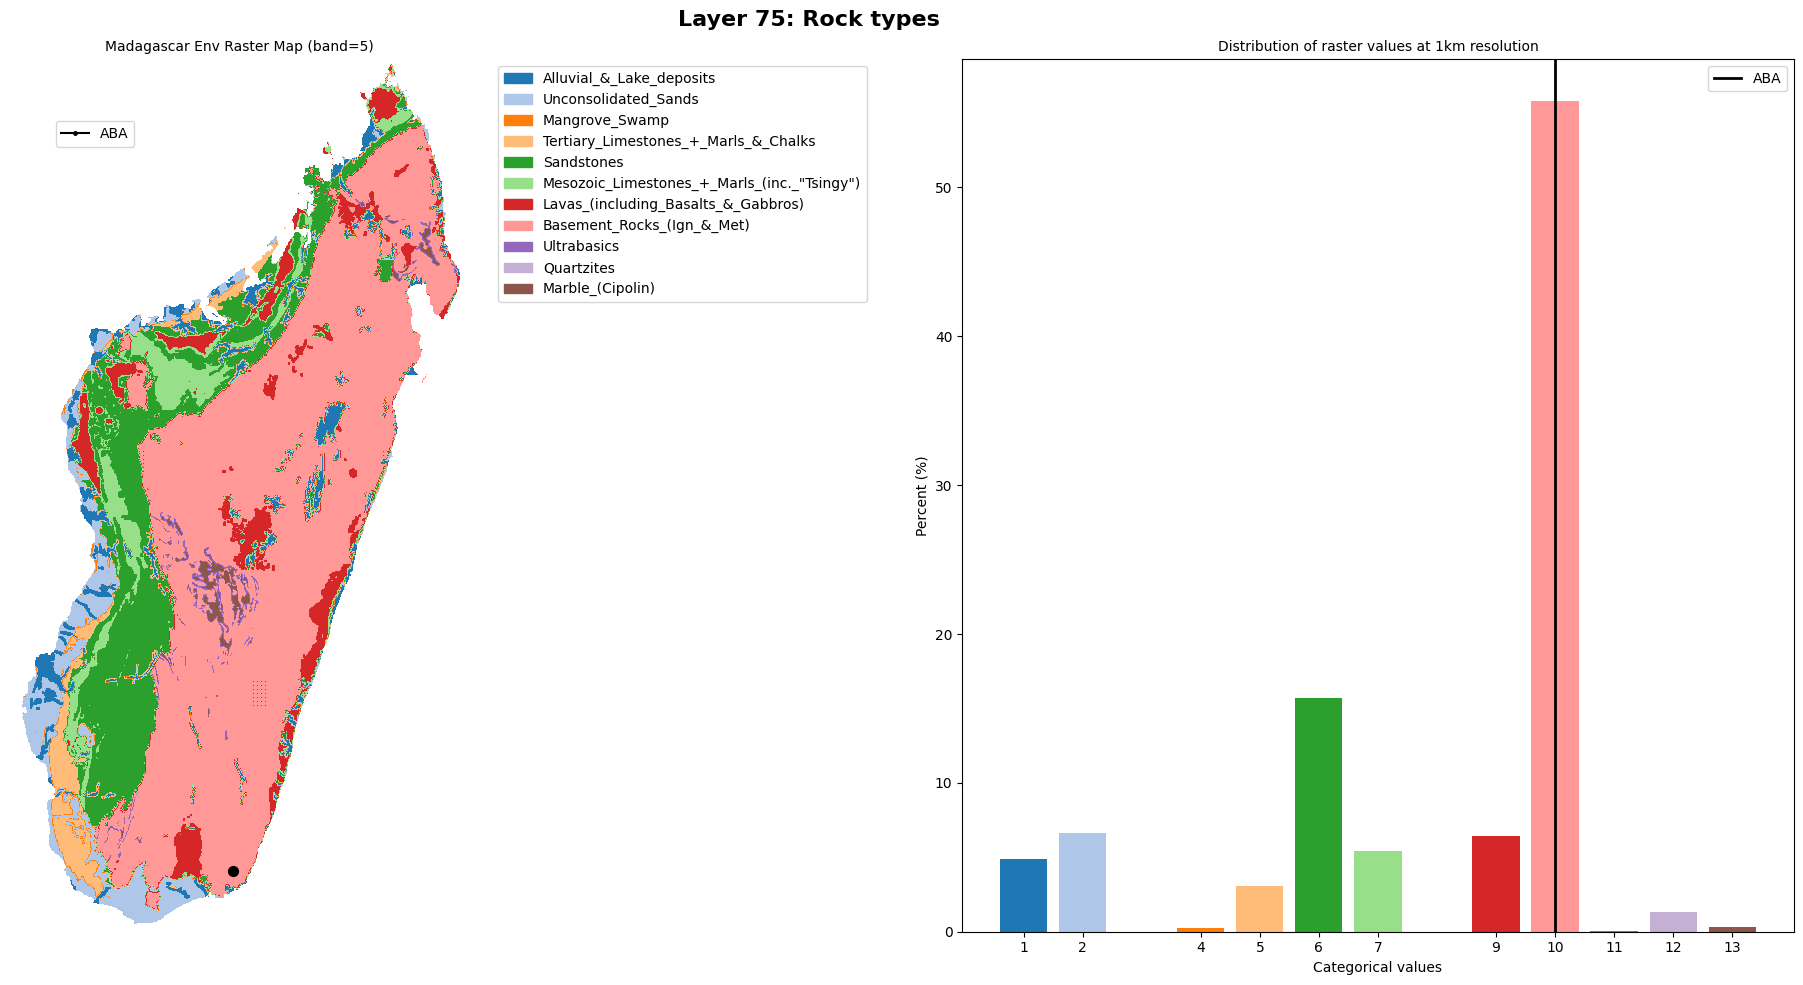

In [156]:
# Base visualization for categorical layers
spe1.plot_on_layer(list(sampled_categ_layers.keys())[0]);

c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


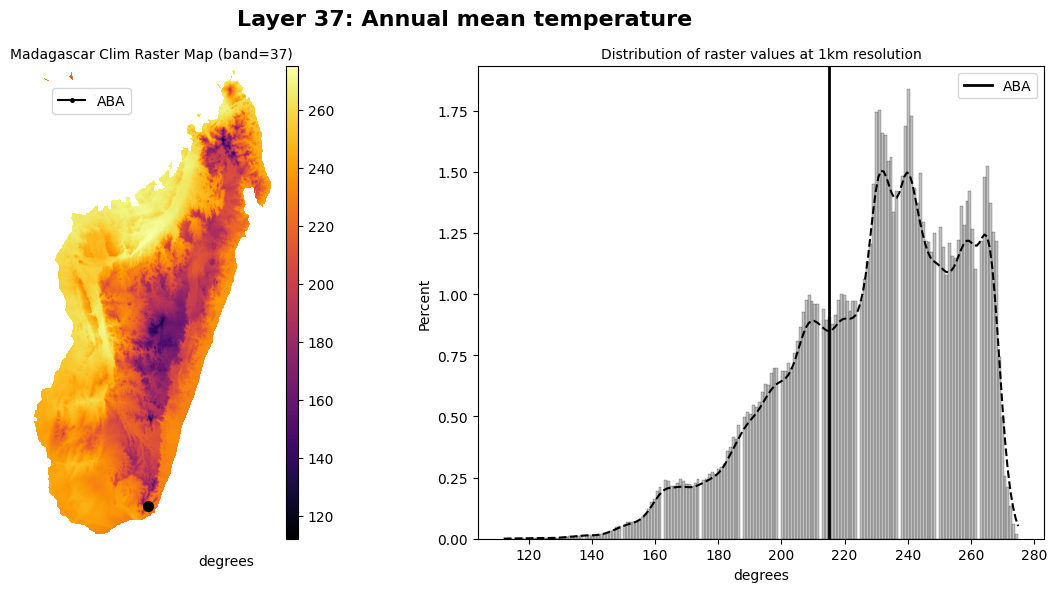

In [157]:
# Base visualization for continuous layers
spe1.plot_on_layer(bioclim_labels[0]);

Customization options for MadaclimPoint on raster map

Use any kwargs that can be passed when customizing the raster map with `imshow_args` (rasterio.plot.show) or the Point with `rasterpoint_args`(geopandas.plot).

*Note: See `MadaclimRasters.plot_layer` method for examples of imshow, cax, histplot parameter customization*

c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


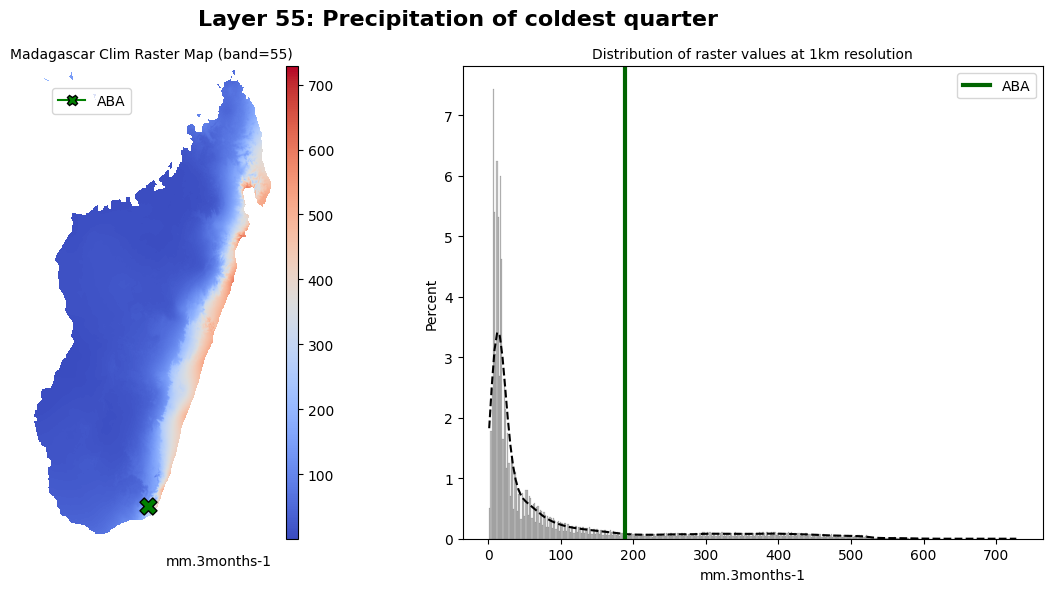

In [158]:
spe1.plot_on_layer(
    layer=bioclim_labels[-1],
    imshow_cmap="coolwarm",
    rasterpoint_color="green", 
    rasterpoint_markersize=150, 
    rasterpoint_marker="X", 
    rasterpoint_edgecolor="black",
    vline_linewidth=3,
    vline_color="darkgreen"
)

## Create a collection of sample points and extract/visualize data from the rasters using `MadaclimCollection`

The `MadaclimCollection` allows grouping of multiple `MadaclimPoint` together and perform operations on the whole set

### Adding or removing points to the `MadaclimCollection`

Let's create 3 `MadaclimPoint` objects

In [159]:
specimen_1 = MadaclimPoint(specimen_id="spe1_aren", latitude=-18.9333, longitude=48.2, genus="Coffea", species="arenesiana", has_sequencing=True)
specimen_2 = MadaclimPoint(specimen_id="spe2_humb", latitude=-12.716667, longitude=45.066667, source_crs=4326, genus="Coffea", species="humblotiana", has_sequencing=True)
specimen_3 = MadaclimPoint(specimen_id="spe3_noncoffea", latitude=-20.138470, longitude=46.054688, family="Rubiaceae", has_sequencing=False, num_samples=1)

Populate the `MadaclimCollection` from an empty collection or using the `add_points` method

In [160]:
from py_madaclim.raster_manipulation import MadaclimCollection

coll = MadaclimCollection()
print(coll)

No MadaclimPoint inside the collection.


In [161]:
# Using the 'add_points' method
coll.add_points([specimen_1, specimen_2, specimen_3])
print(coll)

MadaclimCollection = [
	MadaclimPoint(specimen_id=spe1_aren, lat=-18.933300, lon=48.200000, sampled_layers=False, categ_encoded=False),
	MadaclimPoint(specimen_id=spe2_humb, lat=-12.716667, lon=45.066667, sampled_layers=False, categ_encoded=False),
	MadaclimPoint(specimen_id=spe3_noncoffea, lat=-20.138470, lon=46.054688, sampled_layers=False, categ_encoded=False)
]


In [162]:
# Directly from the constructor
coll = MadaclimCollection(madaclim_points=[specimen_1, specimen_2, specimen_3])
print(coll)

MadaclimCollection = [
	MadaclimPoint(specimen_id=spe1_aren, lat=-18.933300, lon=48.200000, sampled_layers=False, categ_encoded=False),
	MadaclimPoint(specimen_id=spe2_humb, lat=-12.716667, lon=45.066667, sampled_layers=False, categ_encoded=False),
	MadaclimPoint(specimen_id=spe3_noncoffea, lat=-20.138470, lon=46.054688, sampled_layers=False, categ_encoded=False)
]


Remove points or clear the collection

In [163]:
# If objects in the collection have a reference
coll.remove_points(madaclim_points=specimen_2)
coll

MadaclimCollection = [
	MadaclimPoint(specimen_id=spe1_aren, lat=-18.933300, lon=48.200000, sampled_layers=False, categ_encoded=False),
	MadaclimPoint(specimen_id=spe3_noncoffea, lat=-20.138470, lon=46.054688, sampled_layers=False, categ_encoded=False)
]

In [164]:
# Remove by indices
coll = MadaclimCollection(madaclim_points=[specimen_1, specimen_2, specimen_3])
coll.remove_points(indices=-1)
coll

MadaclimCollection = [
	MadaclimPoint(specimen_id=spe1_aren, lat=-18.933300, lon=48.200000, sampled_layers=False, categ_encoded=False),
	MadaclimPoint(specimen_id=spe2_humb, lat=-12.716667, lon=45.066667, sampled_layers=False, categ_encoded=False)
]

Instantiate a `MadaclimCollection` from a '.csv' or a 'dataframe'

In [165]:
# From csv
coll = MadaclimCollection.populate_from_csv(cwd / "collection_example.csv")

Warning! No source_crs column in the csv. Using the default value of EPSG:4326...
Creating MadaclimPoint(specimen_id=ABA...)
Creating MadaclimPoint(specimen_id=AMB...)
Creating MadaclimPoint(specimen_id=ANK1...)
Creating MadaclimPoint(specimen_id=BISS...)
Creating MadaclimPoint(specimen_id=COS...)
Creating MadaclimPoint(specimen_id=VOHE...)
Created new MadaclimCollection with 6 samples.


In [166]:
# From pandas dataframe
import pandas as pd

df = pd.read_csv(cwd / "collection_example.csv")
df

,Species,specimen_id,Botanical series,Genome size (2C. pg),latitude,longitude
0,C.abbayesii,ABA,Millotii,1.25,-24.754100,46.862400
1,C.ambodirianenis,AMB,Millotii,1.27,-18.452200,48.943300
2,C.ankaranensis,ANK1,Multiflorae,1.17,-12.949100,49.543300
3,C.bissetiae,BISS,Baracoffea,1.19,-16.315048,46.812299
4,C.costei,COS,Multiflorae,1.16,-13.750000,50.013300
5,C.vohemarensis,VOHE,Subterminales,1.08,-15.233300,50.141600


In [167]:
coll = MadaclimCollection.populate_from_df(df)

Warning! No source_crs column in the df. Using the default value of EPSG:4326...
Creating MadaclimPoint(specimen_id=ABA...)
Creating MadaclimPoint(specimen_id=AMB...)
Creating MadaclimPoint(specimen_id=ANK1...)
Creating MadaclimPoint(specimen_id=BISS...)
Creating MadaclimPoint(specimen_id=COS...)
Creating MadaclimPoint(specimen_id=VOHE...)
Created new MadaclimCollection with 6 samples.


Access individual points from the collection

In [168]:
# From the 'all_points' list with each objects in the coll
coll.all_points[0]    

MadaclimPoint(
	specimen_id = ABA,
	source_crs = 4326,
	longitude = 46.8624,
	latitude = -24.7541,
	mada_geom_point = POINT (688328.2403248843 7260998.022932809),
	sampled_layers = None (Not sampled yet),
	nodata_layers = None (Not sampled yet),
	is_categorical_encoded = False,
	Species = C.abbayesii,
	Botanical_series = Millotii,
	Genome_size_2C_pg = 1.25,
	gdf.shape = (1, 11)
)

Access the Geopandas dataframe attribute `gdf` based on the `mada_geom_point` geometry of each object

In [169]:
coll.gdf

,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded,Species,Botanical_series,Genome_size_2C_pg
0,ABA,4326,46.862400,-24.754100,POINT (688328.240 7260998.023),None,None,False,C.abbayesii,Millotii,1.25
1,AMB,4326,48.943300,-18.452200,POINT (916635.952 7955240.629),None,None,False,C.ambodirianenis,Millotii,1.27
2,ANK1,4326,49.543300,-12.949100,POINT (993250.150 8564104.062),None,None,False,C.ankaranensis,Multiflorae,1.17
3,BISS,4326,46.812299,-16.315048,POINT (693621.346 8195354.827),None,None,False,C.bissetiae,Baracoffea,1.19
4,COS,4326,50.013300,-13.750000,POINT (1042588.812 8474269.440),None,None,False,C.costei,Multiflorae,1.16
5,VOHE,4326,50.141600,-15.233300,POINT (1052800.567 8309339.860),None,None,False,C.vohemarensis,Subterminales,1.08


In [170]:
# gdf based on the state of the collection
print(f"{coll.sampled_layers=}")
print(f"{coll.nodata_layers=}")

coll.sampled_layers=None
coll.nodata_layers=None


### `MadaclimCollection` sampling and categorical encoding


### Sample from rasters

Just like the `MadaclimPoint` class, use the `sample_from_rasters` method to get data based on the collection's specimens.

In [171]:
coll.sample_from_rasters(
    clim_raster=mada_rasters.clim_raster,
    env_raster=mada_rasters.env_raster,
    layers_to_sample="all",
    layer_info=True
)


######################################## Extracting data for: ABA ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.48 seconds.


######################################## Extracting data for: AMB ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


...


Finished raster sampling operation in 0.48 seconds.


######################################## Extracting data for: VOHE ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.43 seconds.



In [172]:
print(f"Updated Attributes:\n{coll}\n")

print(f"State of {coll.all_points[2].specimen_id} specimen:\n{coll.all_points[2]}")

Updated Attributes:
MadaclimCollection = [
	MadaclimPoint(specimen_id=ABA, lat=-24.754100, lon=46.862400, sampled_layers=True, categ_encoded=False),
	MadaclimPoint(specimen_id=AMB, lat=-18.452200, lon=48.943300, sampled_layers=True, categ_encoded=False),
	MadaclimPoint(specimen_id=ANK1, lat=-12.949100, lon=49.543300, sampled_layers=True, categ_encoded=False),
	MadaclimPoint(specimen_id=BISS, lat=-16.315048, lon=46.812299, sampled_layers=True, categ_encoded=False),
	MadaclimPoint(specimen_id=COS, lat=-13.750000, lon=50.013300, sampled_layers=True, categ_encoded=False),
	MadaclimPoint(specimen_id=VOHE, lat=-15.233300, lon=50.141600, sampled_layers=True, categ_encoded=False)
]

State of ANK1 specimen:
MadaclimPoint(
	specimen_id = ANK1,
	source_crs = 4326,
	longitude = 49.5433,
	latitude = -12.9491,
	mada_geom_point = POINT (993250.1503363774 8564104.062130136),
	len(sampled_layers) = 79 layer(s),
	len(nodata_layers) = None (0 layers),
	is_categorical_encoded = False,
	Species = C.ankaran

Access the sampled layers values for the collection post-sampling

In [173]:
# From the collection's objects
print(list(coll.sampled_layers.keys()))
for specimen_id in coll.sampled_layers:
    print(f"\nSampled layer values for {specimen_id}")
    for layer, value in coll.sampled_layers[specimen_id].items():
        if layer in bioclim_labels[0]:    #print only first bioclim layer
            print(f"{layer} => {value}")    
    

['ABA', 'AMB', 'ANK1', 'BISS', 'COS', 'VOHE']

Sampled layer values for ABA
clim_37_bio1_Annual mean temperature (degrees) => 215

Sampled layer values for AMB
clim_37_bio1_Annual mean temperature (degrees) => 218

Sampled layer values for ANK1
clim_37_bio1_Annual mean temperature (degrees) => 257

Sampled layer values for BISS
clim_37_bio1_Annual mean temperature (degrees) => 265

Sampled layer values for COS
clim_37_bio1_Annual mean temperature (degrees) => 250

Sampled layer values for VOHE
clim_37_bio1_Annual mean temperature (degrees) => 211


In [174]:
# Or from the geodataframe attribute
coll.gdf[["specimen_id"] + bioclim_labels[:1]]

,specimen_id,clim_37_bio1_Annual mean temperature (degrees)
0,ABA,215
1,AMB,218
2,ANK1,257
3,BISS,265
4,COS,250
5,VOHE,211


### Categorical encoding for the collection

In [175]:
print(coll.is_categorical_encoded)

False


Reminder: find out which layer are categorical

In [176]:
categ_layers = mada_info.get_categorical_combinations(as_descriptive_keys=True)
print(list(categ_layers.keys())[0])

env_75_geo_Rock types (categ_vals: 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13)


In [177]:
# No encoding yet
coll.gdf[["specimen_id"] + list(categ_layers.keys())]

,specimen_id,"env_75_geo_Rock types (categ_vals: 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13)","env_76_soi_Soil types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23)","env_77_veg_Vegetation types (categ_vals: 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 22, 23, 25)","env_78_wat_Watersheds (categ_vals: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25)"
0,ABA,10,9,14,5
1,AMB,10,11,14,2
2,ANK1,6,18,7,1
3,BISS,6,16,5,20
4,COS,10,7,7,1
5,VOHE,10,9,14,2


Encode the categorical layers using `binary_encode_categorical`

In [178]:
coll.binary_encode_categorical()
print(coll.is_categorical_encoded)
print(f"Shape of geodataframe post one-hot-encoding: {coll.gdf.shape}")

True
Shape of geodataframe post one-hot-encoding: (6, 169)


The changes are reflected in the `encoded_categ_layers` and `gdf` attributes

In [179]:
# Example for first sample and first categ layer of the collection
{k:v for k,v in list(coll.encoded_categ_layers["ABA"].items())[:12]}

{'env_75_geo_Rock types_Alluvial_&_Lake_deposits': 0,
 'env_75_geo_Rock types_Basement_Rocks_(Ign_&_Met)': 1,
 'env_75_geo_Rock types_Lavas_(including_Basalts_&_Gabbros)': 0,
 'env_75_geo_Rock types_Mangrove_Swamp': 0,
 'env_75_geo_Rock types_Marble_(Cipolin)': 0,
 'env_75_geo_Rock types_Mesozoic_Limestones_+_Marls_(inc._"Tsingy")': 0,
 'env_75_geo_Rock types_Quartzites': 0,
 'env_75_geo_Rock types_Sandstones': 0,
 'env_75_geo_Rock types_Tertiary_Limestones_+_Marls_&_Chalks': 0,
 'env_75_geo_Rock types_Ultrabasics': 0,
 'env_75_geo_Rock types_Unconsolidated_Sands': 0,
 'env_75_geo_Rock types__nodata': 0}

In [180]:
coll.gdf[["specimen_id"] + coll.encoded_categ_labels].iloc[:, :13]

,specimen_id,env_75_geo_Rock types_Alluvial_&_Lake_deposits,env_75_geo_Rock types_Basement_Rocks_(Ign_&_Met),env_75_geo_Rock types_Lavas_(including_Basalts_&_Gabbros),env_75_geo_Rock types_Mangrove_Swamp,env_75_geo_Rock types_Marble_(Cipolin),"env_75_geo_Rock types_Mesozoic_Limestones_+_Marls_(inc._""Tsingy"")",env_75_geo_Rock types_Quartzites,env_75_geo_Rock types_Sandstones,env_75_geo_Rock types_Tertiary_Limestones_+_Marls_&_Chalks,env_75_geo_Rock types_Ultrabasics,env_75_geo_Rock types_Unconsolidated_Sands,env_75_geo_Rock types__nodata
0,ABA,0,1,0,0,0,0,0,0,0,0,0,0
1,AMB,0,1,0,0,0,0,0,0,0,0,0,0
2,ANK1,0,0,0,0,0,0,0,1,0,0,0,0
3,BISS,0,0,0,0,0,0,0,1,0,0,0,0
4,COS,0,1,0,0,0,0,0,0,0,0,0,0
5,VOHE,0,1,0,0,0,0,0,0,0,0,0,0


### Visualize all specimens on the raster map and their sampled values distribution

Let's resample all layers just to simplify the layers' labels

*Note: If there were some layers with 'nodata' values, prints a WARNING! to the console*

In [181]:
coll.sample_from_rasters(
    mada_rasters.clim_raster,
    mada_rasters.env_raster
)


######################################## Extracting data for: ABA ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.42 seconds.


######################################## Extracting data for: AMB ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


...


Finished raster sampling operation in 0.41 seconds.


######################################## Extracting data for: VOHE ########################################

Sampling 70 layer(s) from madaclim_current.tif (geoclim_type=clim)...


Extracting layer 70: Number of dry months in the year:  100%|██████████| layer 70/70 [Time remaining: 00:00]                                              



Sampling 9 layer(s) from madaclim_enviro.tif (geoclim_type=env)...


Extracting layer 79: Percentage of forest cover in 1 km by 1 km grid cells:  100%|██████████| layer 9/9 [Time remaining: 00:00]   



Finished raster sampling operation in 0.44 seconds.



In [182]:
coll.gdf

,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded,Species,Botanical_series,...,layer_70,layer_71,layer_72,layer_73,layer_74,layer_75,layer_76,layer_77,layer_78,layer_79
0,ABA,4326,46.862400,-24.754100,POINT (688328.240 7260998.023),79,0,False,C.abbayesii,Millotii,...,4,350,14,167,6475,10,9,14,5,100
1,AMB,4326,48.943300,-18.452200,POINT (916635.952 7955240.629),79,0,False,C.ambodirianenis,Millotii,...,1,567,8,27,7894,10,11,14,2,65
2,ANK1,4326,49.543300,-12.949100,POINT (993250.150 8564104.062),79,0,False,C.ankaranensis,Multiflorae,...,8,158,12,42,7979,6,18,7,1,20
3,BISS,4326,46.812299,-16.315048,POINT (693621.346 8195354.827),79,0,False,C.bissetiae,Baracoffea,...,8,139,4,39,7846,6,16,5,20,89
4,COS,4326,50.013300,-13.750000,POINT (1042588.812 8474269.440),79,0,False,C.costei,Multiflorae,...,6,40,1,147,7831,10,7,7,1,0
5,VOHE,4326,50.141600,-15.233300,POINT (1052800.567 8309339.860),79,0,False,C.vohemarensis,Subterminales,...,1,657,13,5,8197,10,9,14,2,88


Default visualization for `MadaclimCollection` shows all the points on the specific raster map on the left and the actual values for each point on the right

c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


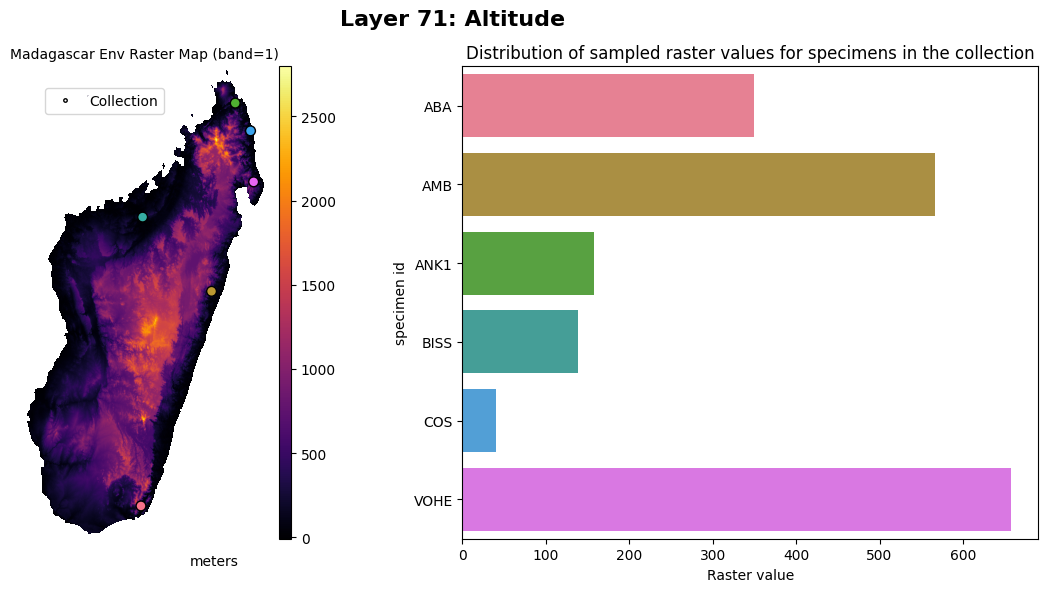

In [183]:
# Base visualization for continuous layers #CF
coll.plot_on_layer(layer="layer_71")

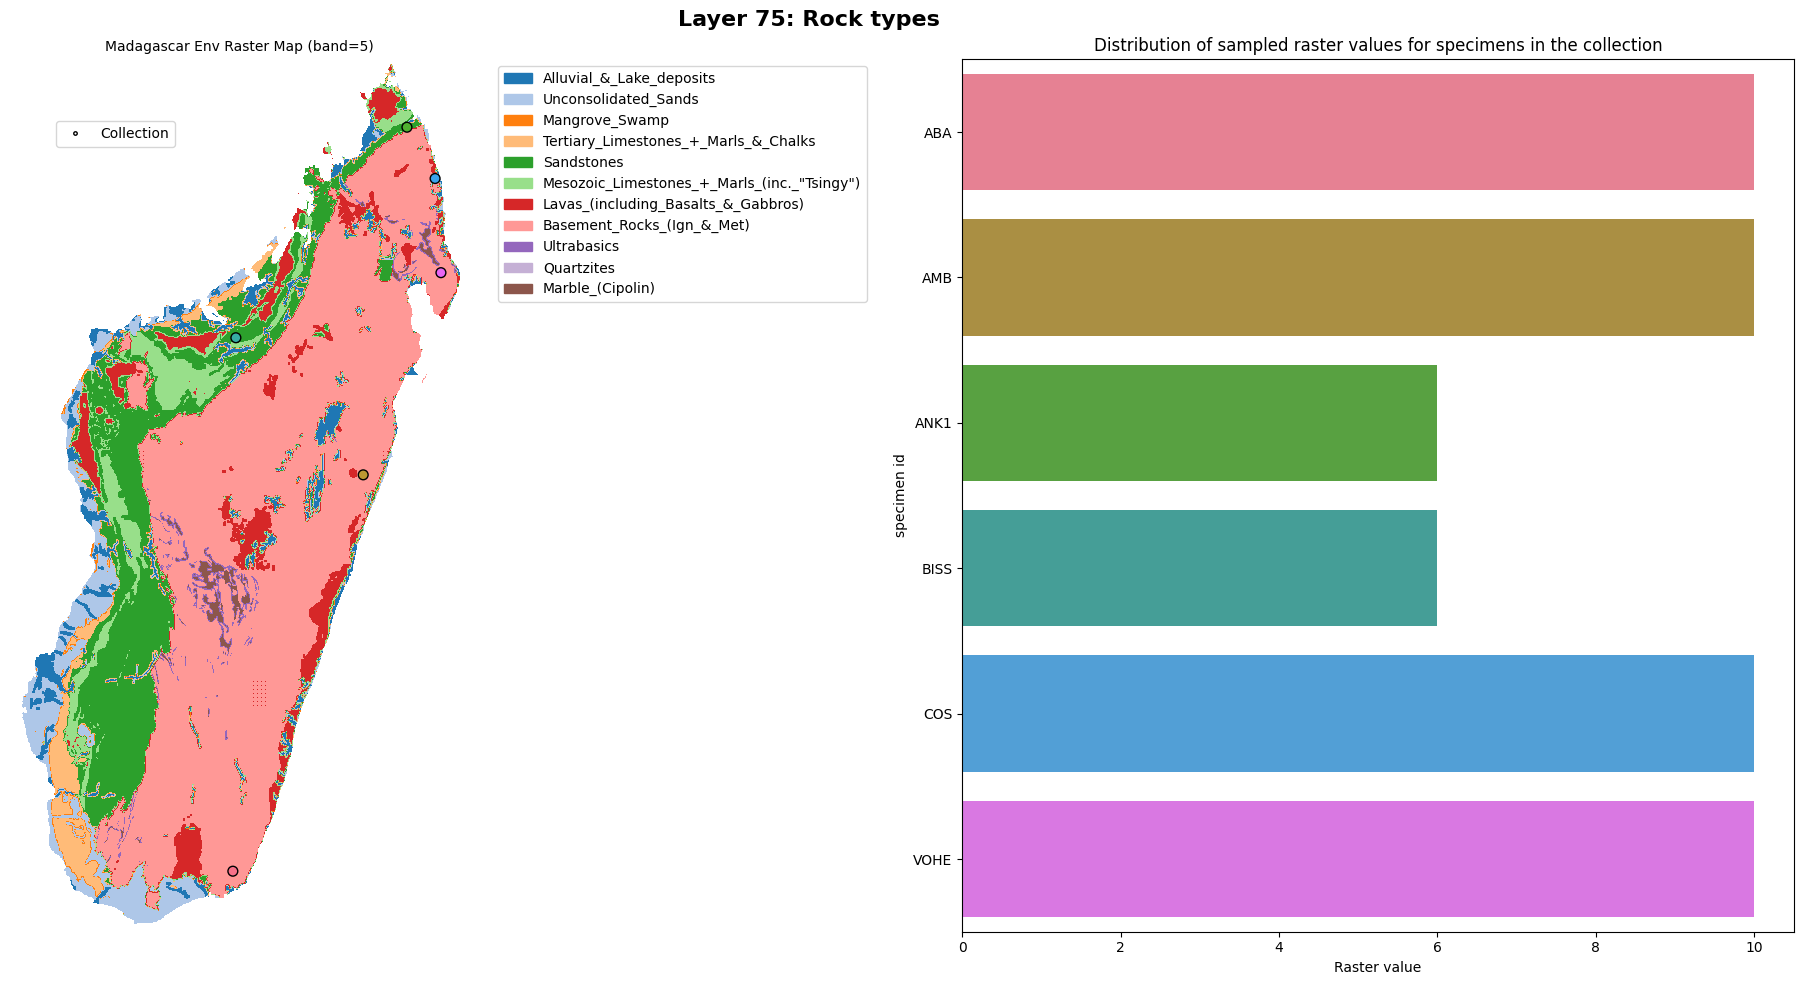

In [184]:
# Base visualization for categorical layers
coll.plot_on_layer("layer_75")

Again, we can customize the plots using both many of the accepted kwargs. Here are some examples with `rasterpoint_<arg>` and `barplot_<arg>` customizations.

In [185]:
mada_info.all_layers

,geoclim_type,layer_number,layer_name,layer_description,is_categorical,units
0,clim,1,tmin1,Monthly minimum temperature - January,False,°C x 10
1,clim,2,tmin2,Monthly minimum temperature - February,False,°C x 10
2,clim,3,tmin3,Monthly minimum temperature - March,False,°C x 10
3,clim,4,tmin4,Monthly minimum temperature - April,False,°C x 10
4,clim,5,tmin5,Monthly minimum temperature - May,False,°C x 10
5,clim,6,tmin6,Monthly minimum temperature - June,False,°C x 10
6,clim,7,tmin7,Monthly minimum temperature - July,False,°C x 10
7,clim,8,tmin8,Monthly minimum temperature - August,False,°C x 10
8,clim,9,tmin9,Monthly minimum temperature - September,False,°C x 10
9,clim,10,tmin10,Monthly minimum temperature - October,False,°C x 10


Customized plot with an example with a missing value for a specimen of the collection

c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


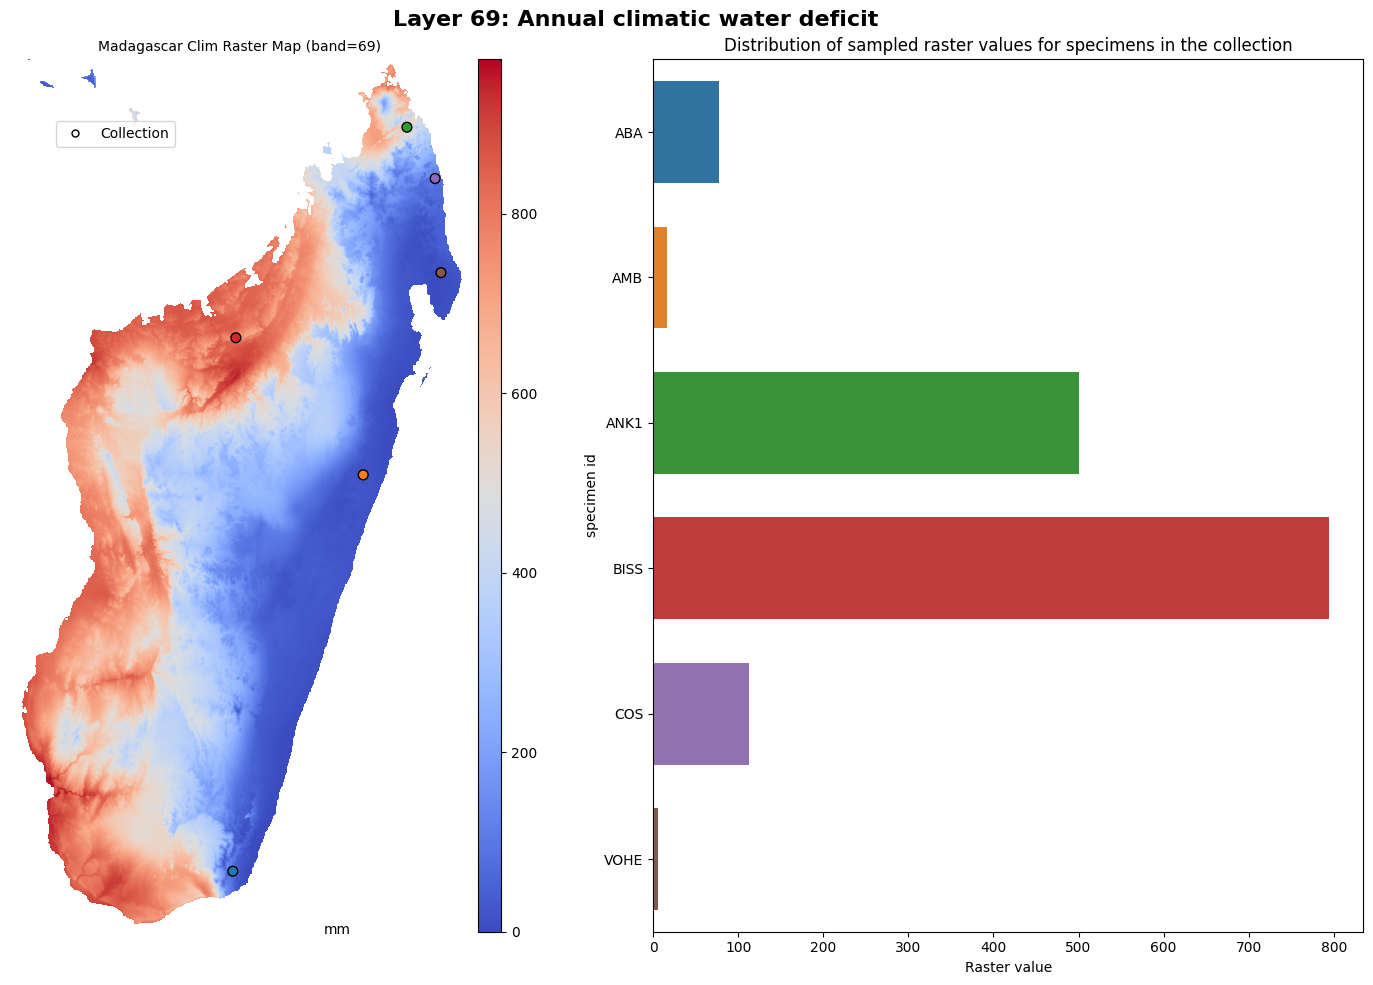

In [186]:
# Continuous layer with customizations
coll.plot_on_layer(
    layer="layer_69",
    subplots_figsize=(15, 10),
    imshow_cmap="coolwarm",
    rasterpoint_marker=".",
    rasterpoint_markersize=200,
    barplot_palette="tab10",    
    barplot_width=0.7,
)

Collection plotting on categorical layer with customizations

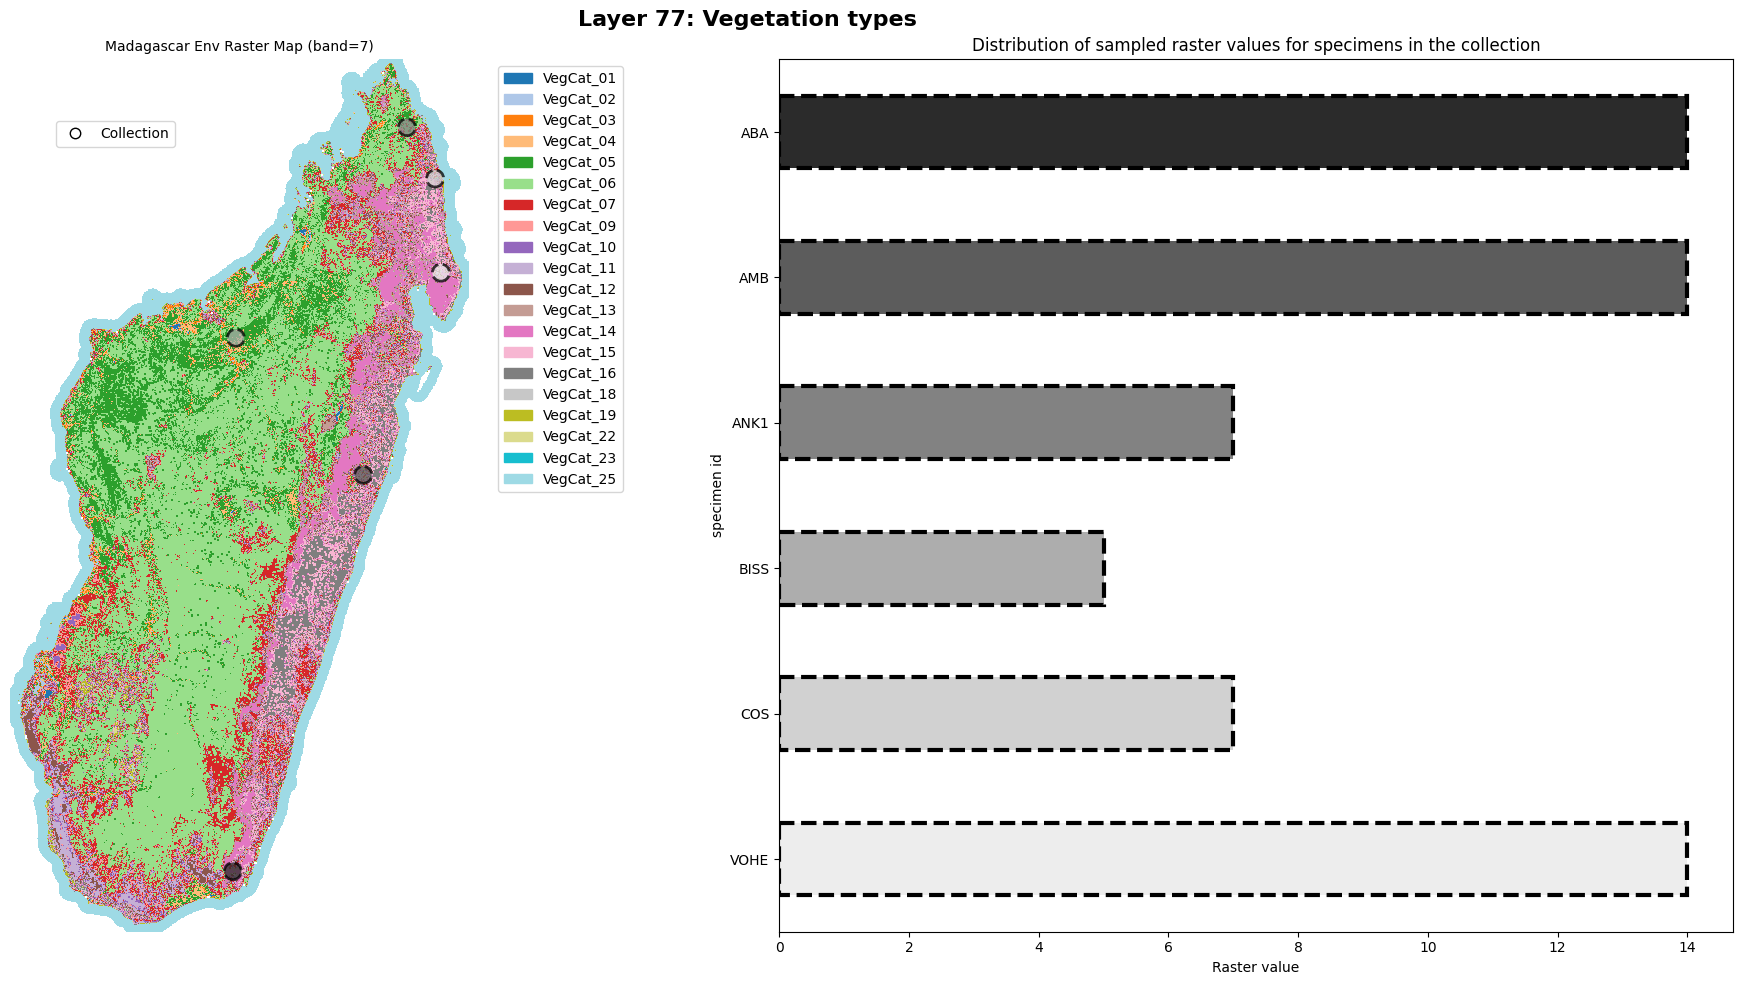

In [187]:
coll.plot_on_layer(
    layer="layer_77",
    rasterpoint_palette="Greys_r",
    rasterpoint_alpha=0.75,
    rasterpoint_markersize=150,
    rasterpoint_linewidths=2,
    rasterpoint_linestyle="--",
    barplot_linewidth=3,
    barplot_edgecolor="black",
    barplot_linestyle="--",
    barplot_width=0.5,
)

## GBIF API utilities included to fetch data prior to using `raster_manipulation` module

### Example: fetch Madagascar coffea species data from GBIF db using the `gbif_api` helper module from `py_madaclim.utils`

In [188]:
from py_madaclim.utils import gbif_api

#### Get taxon key for L. Coffea

In [189]:
# Get GBIF API response for L. Coffea search
gbif_api.get_taxon_key_by_species_match(name="coffea", return_full_on_match=True)

EXACT match type found with 95% confidence!
canonical name of match: Coffea
GBIF_taxon_key: 2895315


{'usageKey': 2895315,
 'scientificName': 'Coffea L.',
 'canonicalName': 'Coffea',
 'rank': 'GENUS',
 'status': 'ACCEPTED',
 'confidence': 95,
 'matchType': 'EXACT',
 'kingdom': 'Plantae',
 'phylum': 'Tracheophyta',
 'order': 'Gentianales',
 'family': 'Rubiaceae',
 'genus': 'Coffea',
 'kingdomKey': 6,
 'phylumKey': 7707728,
 'classKey': 220,
 'orderKey': 412,
 'familyKey': 8798,
 'genusKey': 2895315,
 'synonym': False,
 'class': 'Magnoliopsida'}

In [190]:
# extract taxon_key
coffea_key = gbif_api.get_taxon_key_by_species_match("coffea")

EXACT match type found with 95% confidence!
canonical name of match: Coffea
GBIF_taxon_key: 2895315


#### Search occurences for a given taxon with valid coordinates

In [ ]:
coffea_search_results = gbif_api.search_occ_mdg_valid_coordinates(taxon_key=coffea_key)

Fetching all 2757 occurences accross all possible years...
Extracting occurences 0 to 300...
Extracting occurences 300 to 600...
Extracting occurences 600 to 900...
Extracting occurences 900 to 1200...
Extracting occurences 1200 to 1500...
Extracting occurences 1500 to 1800...


In [ ]:
coffea_search_results[0]["scientificName"]

'Coffea boinensis A.P.Davis & Rakotonas.'

When no year_range are specified, all occurrences are returned. You can filter results upstream of the query using if needed

In [ ]:
coffea_search_results_2010_present = gbif_api.search_occ_mdg_valid_coordinates(
    taxon_key=coffea_key,
    year_range=(2010, 2023)
)

Fetching all 669 occurences in year range 2010-2023...
Extracting occurences 0 to 300...
Extracting occurences 300 to 600...
Extracting occurences 600 to 669...
Total records retrieved: 669


Read the results as a pandas df

In [ ]:
coff_search_df = pd.DataFrame(coffea_search_results_2010_present)
coff_search_df["species"].value_counts()


species
Coffea mangoroensis      64
Coffea richardii         58
Coffea perrieri          48
Coffea sakarahae         24
Coffea boiviniana        23
Coffea resinosa          17
Coffea moratii           17
Coffea millotii          16
Coffea dubardii          15
Coffea heimii            14
Coffea tsirananae        13
Coffea abbayesii         12
Coffea pervilleana       11
Coffea grevei            10
Coffea buxifolia          9
Coffea bissetiae          8
Coffea tricalysioides     7
Coffea sambavensis        6
Coffea arabica            5
Coffea humbertii          5
Coffea liaudii            4
Coffea tetragona          4
Coffea canephora          4
Coffea coursiana          4
Coffea jumellei           3
Coffea bertrandii         3
Coffea arenesiana         2
Coffea toshii             2
Coffea commersoniana      2
Coffea mcphersonii        1
Coffea boinensis          1
Coffea sahafaryensis      1
Coffea liberica           1
Coffea ratsimamangae      1
Coffea pterocarpa         1
Coffea betam

#### Request and download occurrence data in Madagascar for a specific taxon with valid coordinates

**Steps:**
1. We need to create a username in the GBIF website: https://www.gbif.org/ so we can make a post request to the GBIF API
2. Create a `.env` file with our username/password from your GBIF account to be able to make the post request via HTTP Basic auth protocol. Required entries:
    - GBIF_USERNAME="your_username"
    - GBIF_PASSWORD="your_account_password"

    Optional entries:
    - DOWNLOAD_ID="ID_download_request"
    - GBIF_EMAIL="email_for_notification"
    
3. Make the post request for a occurrences search
4. Download the occurences with the download_id 

The `request_occ_download_mdg_valid_coordinates` function will automatically load the `.env` file given the correct dotenv path.

In [ ]:
from dotenv import load_dotenv
# Load dotenv into sys PATH
dotenv_file = cwd / ".env"
assert dotenv_file.is_file()
load_dotenv(dotenv_file)


True

In [ ]:
import os
# Example download query
if os.getenv("DOWNLOAD_ID"):
    print("'DOWNLOAD_ID' found in '.env' file!")
    download_id = os.getenv("DOWNLOAD_ID")
else:
    download_id = gbif_api.request_occ_download_mdg_valid_coordinates(
        taxon_key=coffea_key,
        email=os.getenv("GBIF_EMAIL"),
        dotenv_filepath=dotenv_file,
        reponse_format="DWCA",
        year_range=(2010, 2023)    # Defaults to None which is all possible years
    )

'DOWNLOAD_ID' found in '.env' file!


In [ ]:
# Append to .env file if needed
with open(dotenv_file, "a") as f:
    f.write(f'\nDOWNLOAD_ID="{download_id}"')
load_dotenv(dotenv_file)

True

#### Down, extract and read to memory the occurrence download for samples with valid coordinates

Regardless of format specified in the download post-request, read the occurrence data as a pandas df

In [ ]:
Path.mkdir(cwd / "gbif_example")
coff_dl_df = gbif_api.download_extract_read_occ(
    download_id=os.getenv("DOWNLOAD_ID"),
    target_dir=cwd / "gbif_example"
)

FileExistsError: [WinError 183] Cannot create a file when that file already exists: 'c:\\Users\\forc2101\\OneDrive - USherbrooke\\Documents\\memoire\\py_madaclim\\example\\gbif_example'

We can then use the resulting coordinates and species names to create a MadaclimCollection

In [ ]:
df = coff_dl_df.loc[coff_dl_df["taxonRank"] == "SPECIES"]
df = df.loc[:, ["verbatimScientificName", "decimalLongitude", "decimalLatitude", "year"]]
df = df.reset_index().drop(columns="index")
df["specimen_id"] = df.apply(lambda row: f"{row['verbatimScientificName']}_{row.name}", axis=1)
df["specimen_id"] = df["specimen_id"].str.strip("Coffea ")
df.columns = ["genus_species", "longitude", "latitude", "year", "specimen_id"]
df.head()

,genus_species,longitude,latitude,year,specimen_id
0,Coffea perrieri,46.015693,-17.117573,2023,perrieri_0
1,Coffea pervilleana,45.920397,-17.077081,2023,pervilleana_1
2,Coffea pervilleana,45.923007,-17.078820,2023,pervilleana_2
3,Coffea boiviniana (Baill.) Drake,49.353747,-12.336711,2020,boiviniana (Baill.) Drake_3
4,Coffea humbertii J.-F.Leroy,44.690055,-22.888583,2018,humbertii J.-F.Leroy_4


In [ ]:
# Last 5 years
df_2018_p = df.loc[df["year"] > 2018]
print(len(df_2018_p))

67


In [ ]:
coll = MadaclimCollection.populate_from_df(df_2018_p)

Warning! No source_crs column in the df. Using the default value of EPSG:4326...
Creating MadaclimPoint(specimen_id=perrieri_0...)
Creating MadaclimPoint(specimen_id=pervilleana_1...)
Creating MadaclimPoint(specimen_id=pervilleana_2...)
Creating MadaclimPoint(specimen_id=boiviniana (Baill.) Drake_3...)
Creating MadaclimPoint(specimen_id=humbertii J.-F.Leroy_6...)
Creating MadaclimPoint(specimen_id=humbertii J.-F.Leroy_7...)
Creating MadaclimPoint(specimen_id=tricalysioides_8...)
Creating MadaclimPoint(specimen_id=perrieri Drake ex Jum. & H. Perrier_9...)
Creating MadaclimPoint(specimen_id=perrieri Drake ex Jum. & H. Perrier_16...)
Creating MadaclimPoint(specimen_id=perrieri Drake ex Jum. & H. Perrier_17...)
Creating MadaclimPoint(specimen_id=leroyi A.P. Davis_18...)
Creating MadaclimPoint(specimen_id=resinosa (Hook. f.) Radlk._20...)
Creating MadaclimPoint(specimen_id=richardii J.-F. Leroy_21...)
Creating MadaclimPoint(specimen_id=coursiana J.-F. Leroy_22...)
Creating MadaclimPoint(spe

In [ ]:
coll.gdf.head()

,specimen_id,source_crs,longitude,latitude,mada_geom_point,sampled_layers,nodata_layers,is_categorical_encoded,genus_species,year
0,perrieri_0,4326,46.015693,-17.117573,POINT (608050.722 8107156.468),None,None,False,Coffea perrieri,2023.0
1,pervilleana_1,4326,45.920397,-17.077081,POINT (597933.408 8111686.842),None,None,False,Coffea pervilleana,2023.0
2,pervilleana_2,4326,45.923007,-17.078820,POINT (598210.230 8111493.131),None,None,False,Coffea pervilleana,2023.0
3,boiviniana (Baill.) Drake_3,4326,49.353747,-12.336711,POINT (973765.810 8632361.767),None,None,False,Coffea boiviniana (Baill.) Drake,2020.0
4,humbertii J.-F.Leroy_6,4326,44.136600,-23.531800,POINT (411865.585 7397342.999),None,None,False,Coffea humbertii J.-F.Leroy,2020.0
